In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

import sys, os
sys.path.append(os.path.join(os.getcwd(), "../ml-force"))

from tqdm import tqdm
from ml_force import MorrisLecarCurrent, z_transform, VanDerPol

In [2]:
T = 5000
dt = 1e-1
t = np.arange(0, T, dt)
nt = t.size

In [3]:
supervisor = VanDerPol(T, dt, mu=0.3, tau=0.02).generate(transient_time=100)

supervisor = z_transform(supervisor.T)

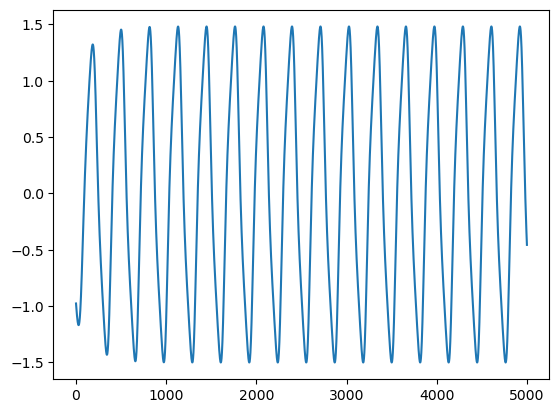

In [4]:
plt.plot(t, supervisor[:, 1])
plt.show()

In [5]:
Ne = 200
Ni = 200
N = Ne + Ni

I = 70      # pA
gbar = 50
Q = 200
delta = 1.0
p_sparse = .1

device = torch.device('cuda')

model = MorrisLecarCurrent(supervisor=supervisor, dt=dt, T=T, Ne=Ne, Ni=Ni, BIAS=I, Q=0, ridge_coeff=delta,
                           gbar=gbar, device=device, p_sparsity=p_sparse)

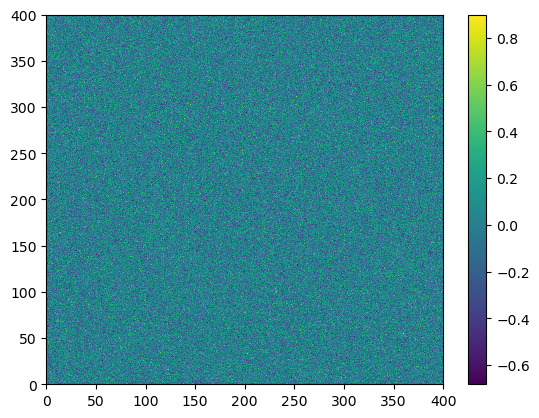

In [6]:
clr = plt.pcolormesh(model.w.cpu().numpy())
plt.colorbar(clr)
plt.show()

## Stress Tests

In [30]:
model.dec = torch.ones(size=(model._N, 2), device=model.device, dtype=torch.float64) * 10

In [7]:
v_trace = torch.zeros((nt, N), device=device, dtype=torch.float32)
s_trace = torch.zeros((nt, N), device=device, dtype=torch.float32)

model.__reinit__()

for i in tqdm(range(nt // 5)):
    model.euler_step()
    v_trace[i] = model.v.squeeze()
    s_trace[i] = model.s.squeeze()

100%|██████████| 10000/10000 [00:03<00:00, 3234.07it/s]


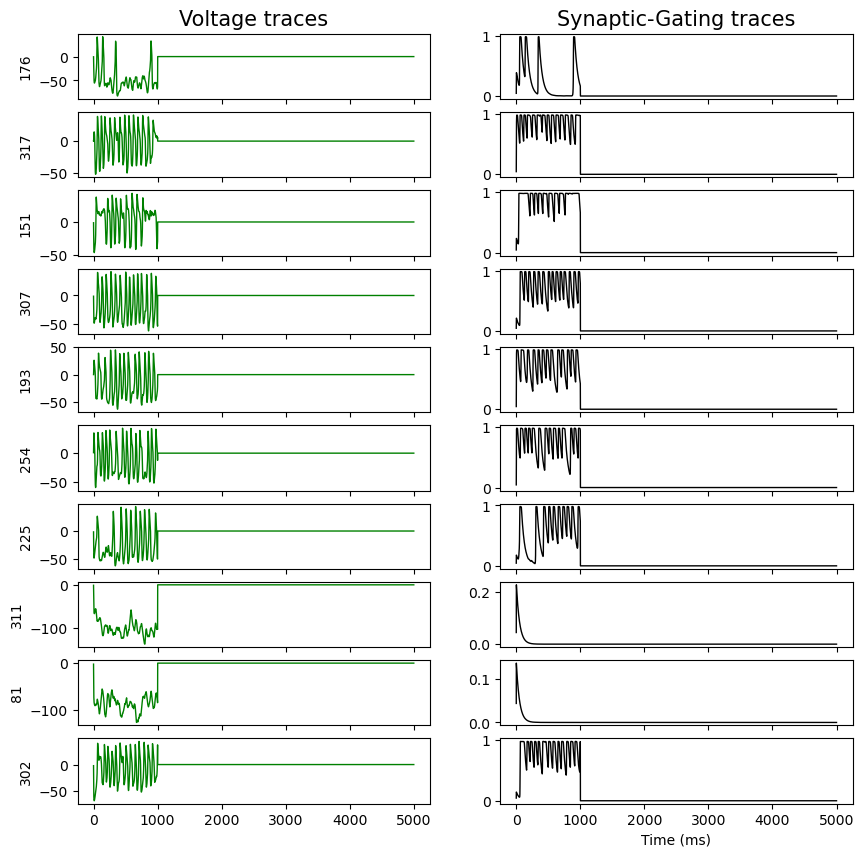

In [8]:
nrows = 10

neurons = np.random.choice(model._N, nrows, replace=False)

fig, ax = plt.subplots(figsize=(10, 10), nrows=nrows, ncols=2, sharex=True)
for i in range(nrows):
    ind = neurons[i]
    ax[i, 0].plot(t, v_trace[:, ind].cpu().numpy(), c='g', lw=1)
    ax[i, 0].set_ylabel(f'{ind}', fontsize=10)
    ax[i, 1].plot(t, s_trace[:, ind].cpu().numpy(), c='k', lw=1)
ax[0, 0].set_title('Voltage traces', fontsize=15)
ax[0, 1].set_title('Synaptic-Gating traces', fontsize=15)
plt.xlabel('Time (ms)', fontsize=10)
plt.show(fig)

## Echo State

In [16]:
def echo_state(model:MorrisLecarCurrent, T:float, dt:float, t_transient:float=200, 
               Q:float=200, I:float=75, n_epochs=5, l_ridge:float=0.01):
    t = np.arange(0, T, dt)
    nt = t.size
    dim = model.sup.shape[1]
    eta = Q * (2 * torch.rand(size=(model._N, dim), device=model.device, dtype=torch.float32) - 1)
    nt_transient = int(t_transient / dt)
    for epoch in range(n_epochs):
        print(f"Epoch {epoch}/{n_epochs}: \n")
        preds = torch.zeros(size=(nt, dim), device=model.device, dtype=torch.float32)
        states = torch.zeros(size=(nt, model._N), device=model.device, dtype=torch.float32)
        model.__reinit__()
        model._BIAS = I
        for _ in tqdm(range(nt_transient)):
            model.euler_step(closed_loop=False)
        
        for i in tqdm(range(nt)):
            model._BIAS = eta @ model.sup[i].reshape(-1, 1)
            model.euler_step()
            preds[i] = model.x_hat.squeeze()
            states[i] = model.s.squeeze()

        loss = torch.mean((preds - model.sup)**2, dim=0, keepdims=True)
        print(f"Loss={loss}")
        # error = preds - model.sup
        z = states - states.mean(axis=0, keepdim=True)
        Pinv = torch.linalg.pinv(z.T @ z + l_ridge * torch.eye(model._N, device=model.device))
        W_new = Pinv @ z.T @ model.sup
        print(W_new.abs().max().item(), W_new.size())
        # update rule for MSE loss with Ridge regression
        model.dec = W_new
        
        plt.plot(t, model.sup[:, 0].cpu().numpy(), 'b-', label="y")
        plt.plot(t, preds[:, 0].cpu().numpy(), 'g-', label="y_hat")
        plt.legend(loc=0)
        plt.show()
        plt.close()
    return model, states, preds, eta

Epoch 0/2: 



100%|██████████| 50000/50000 [00:16<00:00, 3098.26it/s]


Loss=tensor([[0.8919, 0.9225]], device='cuda:0')
0.07241851836442947 torch.Size([400, 2])


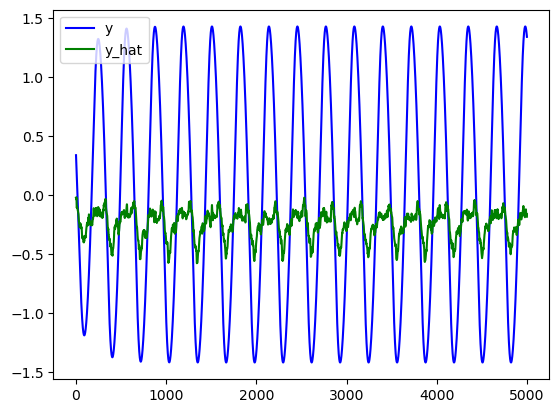

Epoch 1/2: 



100%|██████████| 50000/50000 [00:16<00:00, 3101.47it/s]


Loss=tensor([[0.0222, 0.0012]], device='cuda:0')
0.06641615927219391 torch.Size([400, 2])


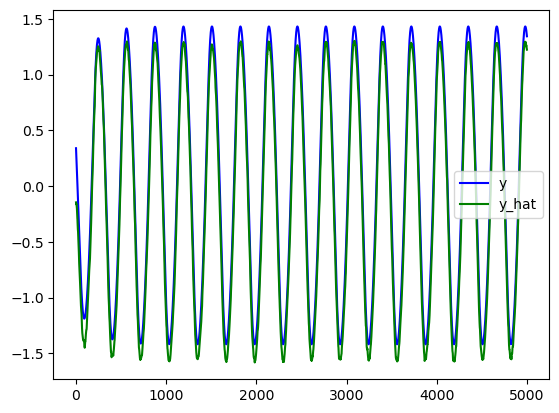

In [17]:
model_trained, states, preds, eta = echo_state(model, T, dt, n_epochs=2, l_ridge=1e-5)

100%|██████████| 50000/50000 [00:16<00:00, 3021.15it/s]


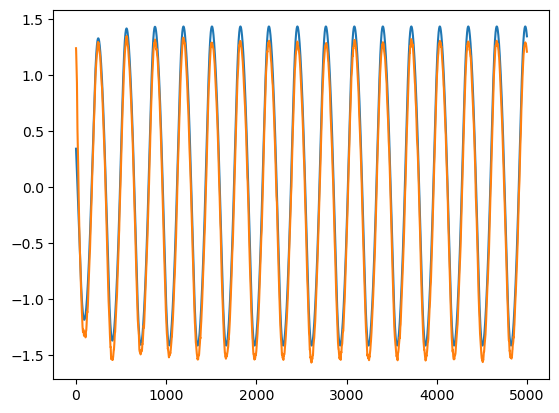

In [18]:
dim = model.sup.shape[1]
preds = torch.zeros(size=(nt, dim), device=model.device, dtype=torch.float32)

for i in tqdm(range(nt)):
    model_trained._BIAS = eta @ model.sup[i].reshape(-1, 1)
    model.euler_step()
    preds[i] = model.x_hat.ravel()

plt.plot(t, supervisor[:, 0])
plt.plot(t, preds[:, 0].cpu().numpy())
plt.show()